In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import defaultdict

In [5]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
#Input Date Preprocssing
# Sample sentence for testing
sentence = "Chen studies Data Science at HSE University"
tokens = sentence.split() # Word-level tokenization
#['Chen', 'studies', 'Data', 'Science', 'at', 'HSE', 'University']
token2idx = {token: i for i, token in enumerate(tokens)}
idx2token = {i: token for i, token in enumerate(tokens)}
seq_len = len(tokens)#7×7

In [7]:
#Self-Attention Implementation
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k, use_scaling=True):
        """
        Implementation of Scaled Dot-Product Attention.
        d_k: Dimension of Queries and Keys.
        use_scaling: Whether to divide by sqrt(d_k).
        """
        super().__init__()
        self.d_k = d_k
        self.use_scaling = use_scaling
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, Q, K, V):
        # Step 1: Compute attention scores (Q @ K^T)
        scores = torch.matmul(Q, K.transpose(-2, -1))

        # Step 2: Scaling (Mitigates vanishing gradients in softmax for high d_k)
        if self.use_scaling:
            scores = scores / torch.sqrt(torch.tensor(self.d_k, dtype=torch.float32))

        # Step 3: Softmax to get weights
        attn_weights = self.softmax(scores)

        # Step 4: Compute context vector
        context = torch.matmul(attn_weights, V)
        return context, attn_weights

In [8]:
#Experimentation Framework
# Experimental Design: 5 comparison groups covering three variables: d_k, d_v, and scaling factor, forming a complete control group.

# Variable 1: d_k (8/64/512) → Validating the impact of dimension on focus

# Variable 2: d_v (8/64/512) → Validating the impact of the value dimension on information capacity

# Variable 3: scaling (True/False) → Validating the necessity of the scaling factor
experimental_configs = [
    {"d_k": 8,   "d_v": 8,   "scaling": True},
    {"d_k": 64,  "d_v": 64,  "scaling": True},
    {"d_k": 64,  "d_v": 64,  "scaling": False}, # Test impact of no scaling
    {"d_k": 128, "d_v": 512, "scaling": True},  # High capacity Value matrix
    {"d_k": 512, "d_v": 512, "scaling": True}
]


results = []

for config in experimental_configs:
    dk, dv, scale = config["d_k"], config["d_v"], config["scaling"]

    # Simulate projected Q, K, V matrices
    Q = torch.randn(seq_len, dk).to(device)# Q shape: [seq_len, d_k] = [7, dk]
    K = torch.randn(seq_len, dk).to(device)
    V = torch.randn(seq_len, dv).to(device)

    attention_layer = ScaledDotProductAttention(d_k=dk, use_scaling=scale).to(device)

    # Measure latency (Computational Cost)
    start_time = time.time()
    context, weights = attention_layer(Q, K, V)
    latency = (time.time() - start_time) * 1000 # ms

    # Metrics for analysis
    weights_np = weights.cpu().detach().numpy()
    # Entropy: Higher means attention is spread out (failed focus)
    entropy = -np.sum(weights_np * np.log2(weights_np + 1e-9)) / seq_len
    # Variance: Higher means context vectors are more distinct
    context_var = np.var(context.cpu().detach().numpy())

    results.append({
        "Config": f"K{dk}_V{dv}_S{int(scale)}",
        "d_k": dk,
        "d_v": dv,
        "Scaling": scale,
        "Latency(ms)": round(latency, 4),
        "Entropy": round(entropy, 4),
        "Variance": round(context_var, 4),
        "Weights": weights_np
    })

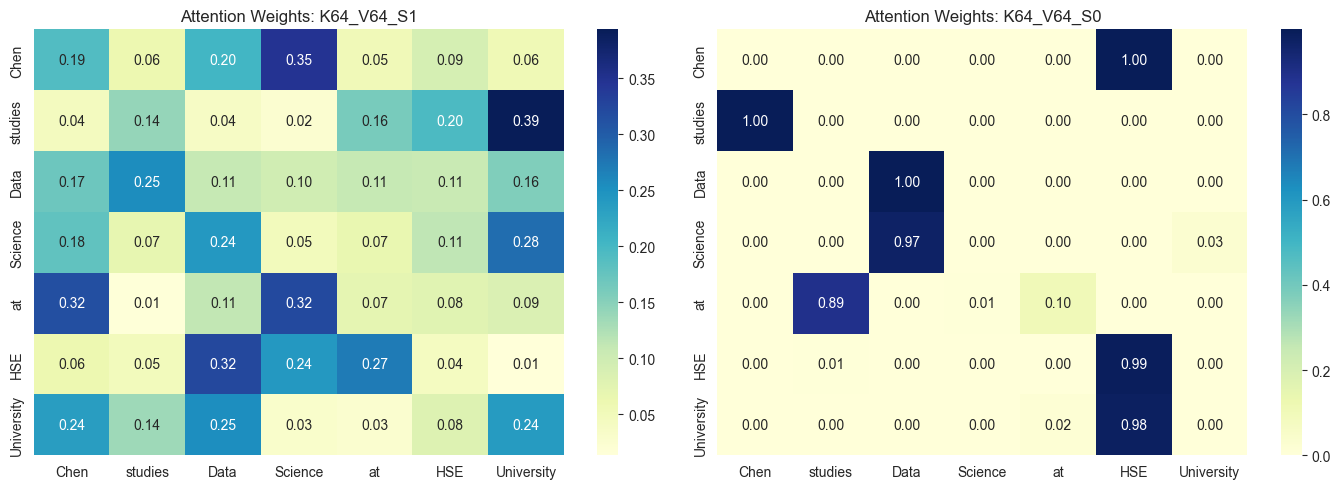


Configuration   | Latency(ms)  | Entropy    | Variance   | Success?
-------------------------------------------------------------------------------------
K8_V8_S1        | 0.5112       | 2.3922998905181885 | 0.24060000479221344 | Partial
K64_V64_S1      | 0.0808       | 2.4489998817443848 | 0.19920000433921814 | Partial
K64_V64_S0      | 0.066        | 0.14309999346733093 | 0.9835000038146973 | Yes
K128_V512_S1    | 0.0761       | 2.258699893951416 | 0.25220000743865967 | Partial
K512_V512_S1    | 0.0901       | 2.1953999996185303 | 0.2809000015258789 | Partial


In [9]:
#Visualization
# Heatmap comparison (Standard vs No Scaling)
plt.figure(figsize=(14, 5))
for i, idx in enumerate([1, 2]): # Compare Scaled vs Unscaled at d_k=64
    plt.subplot(1, 2, i+1)
    sns.heatmap(results[idx]["Weights"], annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=tokens, yticklabels=tokens)
    plt.title(f"Attention Weights: {results[idx]['Config']}")
plt.tight_layout()
plt.show()

# Summary Table for Assignment Report
print("\n" + "="*85)
print(f"{'Configuration':<15} | {'Latency(ms)':<12} | {'Entropy':<10} | {'Variance':<10} | {'Success?'}")
print("-" * 85)
for res in results:
    # A config is "successful" if it's focused (lower entropy) but feature-rich (variance)
    status = "Yes" if res["Entropy"] < 2.5 and res["Variance"] > 0.5 else "Partial"
    print(f"{res['Config']:<15} | {res['Latency(ms)']:<12} | {res['Entropy']:<10} | {res['Variance']:<10} | {status}")
print("="*85)